In [1]:
import pickle
import matplotlib.pyplot as plt

%matplotlib ipympl

# Computing Bounding Boxes

In [ ]:
import mesh_generation

id0 = './david/grab_1/'
pts3_0, pts2L_0, pts2R_0, colors_0 = mesh_generation.get_corresponding_points(id0, decode_threshold=0.005, color_threshold=0.01)

Largest Bounding Box: [np.float64(1.6684388664560075), np.float64(30.35088521495676), np.float64(-2.9331808604560505), np.float64(20.28833978826025), np.float64(2.365941238291189), np.float64(30.339578248603253)]


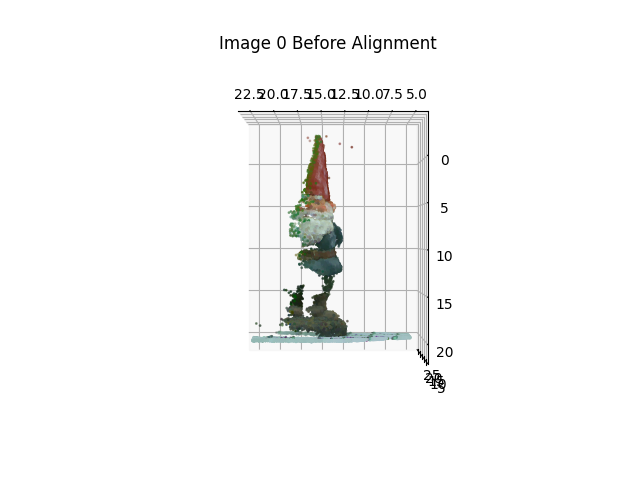

In [ ]:
# Perform bounding box alignment for both sets of points
bounding_box_0 = [5, 22, # left-right
                -3, 21, # down-up
                5, 22.5] # out in

pts3_0, pts2L_0, pts2R_0, colors_0 = mesh_generation.bounding_box_pruning(pts3_0, pts2L_0, pts2R_0, colors_0, bounding_box_0)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pts3_0[0, :], pts3_0[1, :], pts3_0[2, :], c=colors_0.T, s=1)
ax.set_title('Image 0 Before Alignment')
ax.axis('equal')
ax.view_init(elev=0, azim=-180, roll=90)

pickle.dump((pts3_0, pts2L_0, pts2R_0, colors_0), open('./david/grab_1/points.pkl', 'wb'))
pickle.dump(bounding_box_0, open('./david/grab_1/bounding_box.pkl', 'wb'))

# Combining Scans

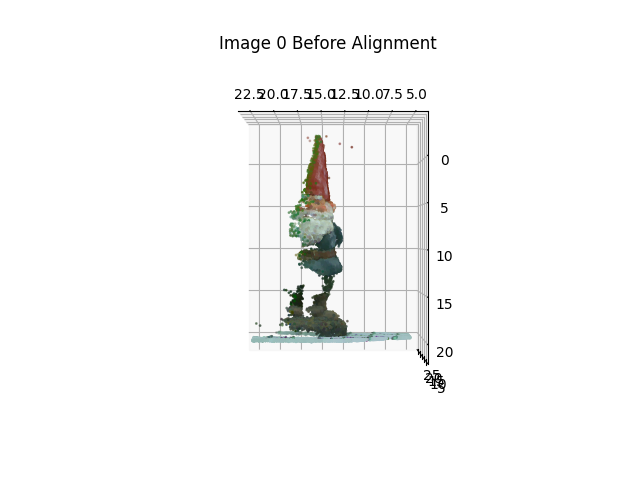

Average alignment error for ./david_undistorted/grab_2/ to ./david_undistorted/grab_1/: 1.8493990241090394
Per-point errors: [4.07665777 1.15659536 0.31494395]
Average alignment error for ./david_undistorted/grab_3/ to ./david_undistorted/grab_2/: 1.6007069717037923
Per-point errors: [2.60594657 0.94502492 0.65859411 2.19326229]
Average alignment error for ./david_undistorted/grab_4/ to ./david_undistorted/grab_3/: 1.2410788450473509
Per-point errors: [0.88246227 1.59211894 1.24865532]
Average alignment error for ./david_undistorted/grab_0/ to ./david_undistorted/grab_4/: 0.681327570379886
Per-point errors: [0.76221447 0.98445909 0.29730915]


In [ ]:
%matplotlib tk

import matplotlib.image as mpimg
import pickle
import numpy as np

from correspond import select_3d_correspondences, svd_alignment, transform_points, icp_point_to_point

# Align each scan to the previous view, then compose transforms into grab_1 coordinates
points = []
points_2d = []
colors = []

previous_num = 1
previous_id = './david/grab_1/'
previous_img = mpimg.imread(previous_id + 'color_C0_01_u.png')

pts3_previous, pts2L_previous, pts2R_previous, colors_previous = pickle.load(
    open(previous_id + 'points.pkl', 'rb')
)

points.append(pts3_previous)
points_2d.append(pts2L_previous)
colors.append(colors_previous)

# Transform from the previous scan's coordinates into grab_1 coordinates.
R_previous_to_base = np.eye(3)
t_previous_to_base = np.zeros((3, 1))

for current_id in ['./david/grab_2/', './david/grab_3/', './david/grab_4/', './david/grab_0/']:
    current_num = current_id.strip('/').split('_')[-1]

    current_img = mpimg.imread(current_id + 'color_C0_01_u.png')

    pts3_current, pts2L_current, pts2R_current, colors_current = pickle.load(
        open(current_id + 'points.pkl', 'rb')
    )

    P_previous, Q_current = select_3d_correspondences(
        previous_img, pts2L_previous, pts3_previous,
        current_img, pts2L_current, pts3_current,
        max_dist=10,
    )

    R0, t0 = svd_alignment(Q_current, P_previous)
    
    R_pair, t_pair, _ = icp_point_to_point(
        pts3_current,
        pts3_previous,
        R_init=R0,
        t_init=t0,
        max_iters=10,
        max_match_dist=1.5
    )

    np.savez(
        f"rigid_transform_{current_num}_to_{previous_num}.npz",
        R=R_pair,
        t=t_pair,
    )

    # current -> previous -> grab_1
    R_current_to_base = R_previous_to_base @ R_pair
    t_current_to_base = R_previous_to_base @ t_pair + t_previous_to_base
    pts3_current_aligned = transform_points(
        pts3_current, R_current_to_base, t_current_to_base
    )
    np.savez(
        f"rigid_transform_{current_num}_to_1.npz",
        R=R_current_to_base,
        t=t_current_to_base,
    )

    points.append(pts3_current_aligned)
    points_2d.append(pts2L_current)
    colors.append(colors_current)

    aligned_Q = transform_points(Q_current, R_pair, t_pair)
    errs = np.linalg.norm(aligned_Q - P_previous, axis=0)

    print(f"Average alignment error for {current_id} to {previous_id}: {errs.mean()}")
    print("Per-point errors:", errs)

    # This raw scan becomes the target for the next pairwise alignment.
    previous_num = current_num
    previous_id = current_id
    previous_img = current_img
    pts3_previous = pts3_current
    pts2L_previous = pts2L_current
    pts2R_previous = pts2R_current
    colors_previous = colors_current
    R_previous_to_base = R_current_to_base
    t_previous_to_base = t_current_to_base
    
# Save the aligned points and colors for all scans

pickle.dump((points, points_2d, colors), open('./david/grab_4/combined_points.pkl', 'wb'))

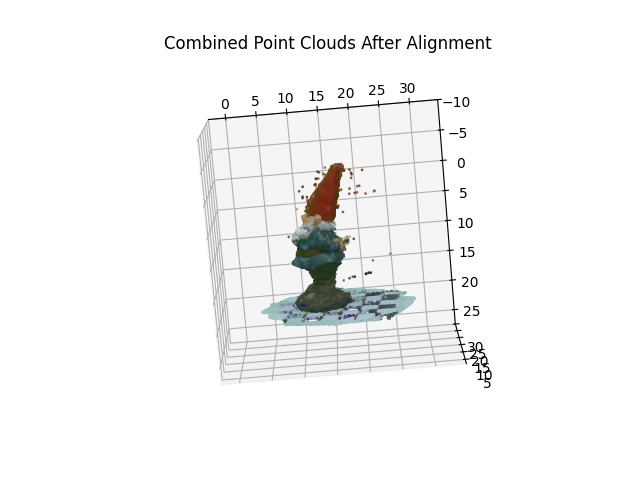

In [9]:
%matplotlib ipympl

# Load points for scan A and scan B on same plot

import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for pts3, color in zip(points, colors):
    ax.scatter(pts3[0, :], pts3[1, :], pts3[2, :], c=color.T, s=1)

ax.set_title('Combined Point Clouds After Alignment')
ax.axis('equal')
ax.view_init(elev=-80, azim=-85)

# Removing Green Background Points

In [ ]:
%matplotlib ipympl

import mesh_generation
import pickle
import numpy as np

points, points_2d, colors = pickle.load(open('./david/grab_4/combined_points.pkl', 'rb'))

def remove_green_points(pts3, pts2d, colors, green_thresh=0.02):
    """
    pts3: 3 x N point cloud
    colors: 3 x N RGB values (0-255)

    Removes points where G is significantly larger than R and B.
    """

    R = colors[0]
    G = colors[1]
    B = colors[2]

    mask = ~(
        (G > 0.3) &
        (G - R > green_thresh) &
        (G - B > green_thresh)
    )

    return pts3[:, mask], pts2d[:, mask], colors[:, mask]

for i in range(len(points)):
    points[i], points_2d[i], colors[i] = remove_green_points(points[i], points_2d[i], colors[i])

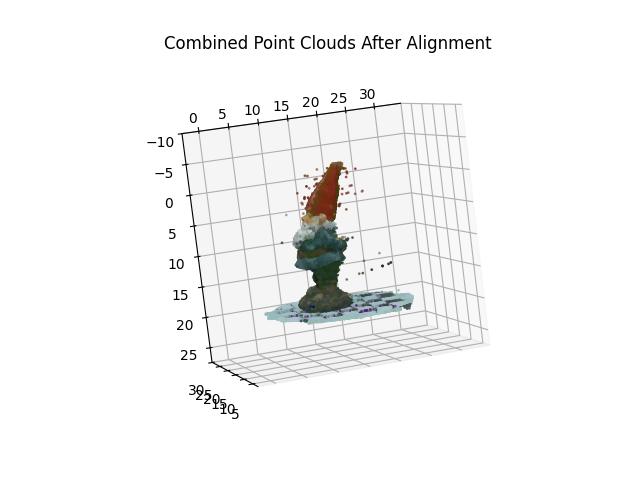

In [8]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for pts3, color in zip(points, colors):
    ax.scatter(pts3[0, :], pts3[1, :], pts3[2, :], c=color.T, s=1)

ax.set_title('Combined Point Clouds After Alignment')
ax.axis('equal')
ax.view_init(elev=-72, azim=-159, roll=77)

In [ ]:
# Save new points after removing green

pickle.dump((points, points_2d, colors), open('./david/grab_4/combined_points.pkl', 'wb'))

# Final Bounding Box Cleaning

In [ ]:
%matplotlib ipympl

import mesh_generation
import pickle
import numpy as np

def bounding_box_pruning(pts3, pts2L, colors, bounding_box=None):
    # Bounding box pruning

    X = pts3[0, :]
    Y = pts3[1, :]
    Z = pts3[2, :]

    if bounding_box is None:
        bounding_box = (X.min(), X.max(), Y.min(), Y.max(), Z.min(), Z.max())
    
    keep = (
        (X >= bounding_box[0]) & (X <= bounding_box[1]) &
        (Y >= bounding_box[2]) & (Y <= bounding_box[3]) &
        (Z >= bounding_box[4]) & (Z <= bounding_box[5])
    )
    
    pts3_pruned = pts3[:, keep]
    pts2L_pruned = pts2L[:, keep]
    colors_pruned = colors[:, keep]

    return pts3_pruned, pts2L_pruned, colors_pruned

points, points_2d, colors = pickle.load(open('./david/grab_4/combined_points.pkl', 'rb'))

# Perform bounding box alignment for both sets of points
bounding_box = [9, 18, # left-right
                -3, 18.5, # down-up
                5, 22.5] # out in

for i in range(len(points)):
    points[i], points_2d[i], colors[i] = bounding_box_pruning(points[i], points_2d[i], colors[i], bounding_box)

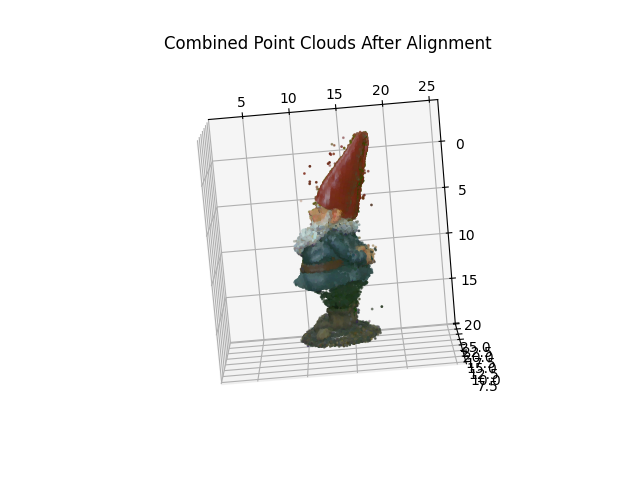

In [13]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for pts3, color in zip(points, colors):
    ax.scatter(pts3[0, :], pts3[1, :], pts3[2, :], c=color.T, s=1)

ax.set_title('Combined Point Clouds After Alignment')
ax.axis('equal')
ax.view_init(elev=-80, azim=-85)

In [ ]:
# Save new points after additional bounding box filtering

pickle.dump((points, points_2d, colors), open('./david/grab_4/combined_points.pkl', 'wb'))

# Triangulation

In [ ]:
import mesh_generation
import pickle
import numpy as np

# Then perform Delaunay triangulation on the combined point cloud

points, points_2d, colors = pickle.load(open('./david/grab_4/combined_points.pkl', 'rb'))

In [ ]:
all_pts = []
all_colors = []
all_triangles = []

offset = 0

thresh_arr = [1.2, 1.2, 1.2, 1.2, 1.2]

for pts3_scan, pts2_scan, colors_scan, trithresh in zip(points, points_2d, colors, thresh_arr):
    pts3_m, tri_m, colors_m, pts2L_m = mesh_generation.create_mesh(
        pts3_scan, pts2_scan, colors_scan, trithresh=trithresh
    )

    all_pts.append(pts3_m)
    all_colors.append(colors_m)
    all_triangles.append(tri_m + offset)

    offset += pts3_m.shape[1]

combined_pts3 = np.hstack(all_pts)
combined_colors = np.hstack(all_colors)
combined_triangles = np.vstack(all_triangles)

# Save the combined points and colors for later use

pickle.dump((combined_pts3, combined_colors, combined_triangles), open('./david/grab_4/final_mesh.pkl', 'wb'))

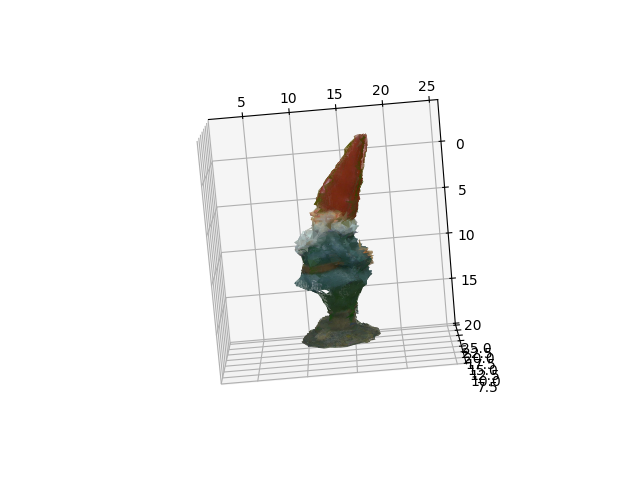

In [ ]:
# Load non-smoothed mesh results and visualize
import pickle
import matplotlib.pyplot as plt
import numpy as np

combined_pts3, combined_colors, combined_triangles = pickle.load(open('./david/grab_4/final_mesh.pkl', 'rb'))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
mesh = ax.plot_trisurf(
    combined_pts3[0, :],
    combined_pts3[1, :],
    combined_pts3[2, :],
    triangles=combined_triangles,
    shade=False
)
ax.view_init(elev=-80, azim=-85)
face_colors = np.mean(
    combined_colors.T[combined_triangles],
    axis=1
)
ax.axis('equal')

mesh.set_facecolors(face_colors)

plt.show()

import trimesh 
mesh = trimesh.Trimesh(vertices=combined_pts3.T, faces=combined_triangles[:, [0, 2, 1]])
mesh.show()


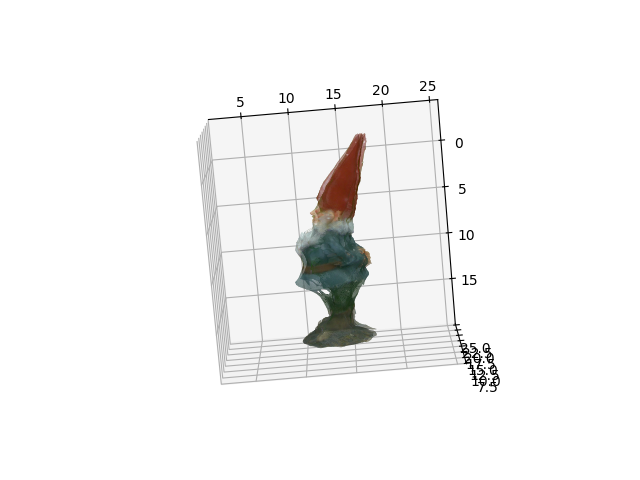

In [17]:
# Mesh Smoothing

smoothed_pts3 = mesh_generation.mesh_smoothing(combined_pts3, combined_triangles, iterations=10)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
mesh = ax.plot_trisurf(
    smoothed_pts3[0, :],
    smoothed_pts3[1, :],
    smoothed_pts3[2, :],
    triangles=combined_triangles,
    shade=False
)
ax.view_init(elev=-80, azim=-85)
face_colors = np.mean(
    combined_colors.T[combined_triangles],
    axis=1
)
ax.axis('equal')

mesh.set_facecolors(face_colors)

plt.show()

import trimesh 
mesh = trimesh.Trimesh(vertices=smoothed_pts3.T, faces=combined_triangles[:, [0, 2, 1]])
mesh.show()

In [33]:
# Save final mesh as .ply file
from meshutils import writeply

writeply(combined_pts3, combined_colors, combined_triangles, "david_mesh.ply")

writeply(smoothed_pts3, combined_colors, combined_triangles, "david_smoothed_mesh.ply")